# PPO GridWorld：训练、确定性 baseline 与可视化

本 notebook 只负责组织已有架构：`GridWorld_Config → GridWorld → Actor/Critic → GridWorld_Rollout → GridWorld_Runner`。训练数据只来自环境交互；值迭代 baseline 仅用于训练外评估，不作为网络标签。

目标格在到达时终止；惩罚格可进入但获得负奖励。部署策略使用 Actor logits 的 `argmax`，因此是确定性策略。

## 1. 导入与工作区定位

In [22]:
from pathlib import Path
import json
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display

cwd = Path.cwd().resolve()
workspace = next((p for p in (cwd, *cwd.parents) if (p / 'code' / 'PPO').is_dir()), None)
if workspace is None:
    raise RuntimeError('请从包含 code/PPO 的工作区内启动 notebook。')
ppo_dir = workspace / 'code' / 'PPO'
if str(ppo_dir) not in sys.path:
    sys.path.insert(0, str(ppo_dir))

# env.py 使用了旧版 NumPy 的两个类型别名；在不修改原文件的前提下局部兼容。
np.__dict__.setdefault('long', np.int64)
np.__dict__.setdefault('bool', np.bool_)

from config import GridWorld_Config
from env import GridWorld
from net import Actor, Critic
from rollout import GridWorld_Rollout
from runner import GridWorld_Runner
from evaluate import evaluate, optimal_reference
from vizualize import (
    plot_baseline_comparison,
    plot_evaluation_curve,
    plot_policy,
    plot_training_curve,
)

## 2. 集中配置

`steps_per_env × rollout_batch` 是一次 rollout 的样本数，必须不小于 `batch_size`。`updates_per_rollout` 表示同一批 on-policy 数据执行多少次小批量 PPO 更新。

In [23]:
cfg = GridWorld_Config(
    # 随机性
    rand_seed=123456,

    # 环境：0=普通格，1=可进入的惩罚格，2=终止目标
    row_num=5,
    col_num=5,
    rewards={'blank': 0, 'boundary': -10, 'forbidden': -100, 'target': 100},
    grid=[
        [0, 0, 0, 0, 0],
        [0, 1, 1, 0, 0],
        [0, 0, 1, 0, 0],
        [0, 1, 2, 1, 0],
        [0, 1, 0, 0, 0],
    ],
    action2dx={0: -1, 1: 0, 2: 1, 3: 0, 4: 0},
    action2dy={0: 0, 1: 1, 2: 0, 3: -1, 4: 0},
    idx2grid={0: 'blank', 1: 'forbidden', 2: 'target'},

    # Actor / Critic
    input_dim=25,
    action_dim=5,
    actor_hidden_dim=[64, 64],
    critic_hidden_dim=[64, 64],

    # Rollout 与 PPO
    steps_per_env=32,
    rollout_batch=100,
    gamma=0.95,
    clip_eps=0.2,
    entropy_coef_start=0.1,
    entropy_coef_end=0.001,
    batch_size=256,
    actor_lr=3e-4,
    critic_lr=3e-4,

    # train config
    train_iterations=2000,
    update_per_iter=5
)

# Notebook 运行参数（不属于 GridWorld_Config）
evaluation_interval = 10
smoothing_window = 20
output_dir = workspace / 'output' / 'ppo'
save_figures = True
show_figures = True
figure_dpi = 180

if cfg.input_dim != cfg.row_num * cfg.col_num:
    raise ValueError('input_dim 必须等于 row_num * col_num。')
if cfg.steps_per_env * cfg.rollout_batch < cfg.batch_size:
    raise ValueError('一次 rollout 的样本数不能小于 batch_size。')
if save_figures:
    output_dir.mkdir(parents=True, exist_ok=True)

print(json.dumps({
    'grid_shape': [cfg.row_num, cfg.col_num],
    'samples_per_rollout': cfg.steps_per_env * cfg.rollout_batch,
    'training_rollouts': cfg.train_iterations,
    'updates_per_rollout': cfg.update_per_iter,
    'evaluation_interval': evaluation_interval,
    'output_dir': str(output_dir),
}, indent=2, ensure_ascii=False))

{
  "grid_shape": [
    5,
    5
  ],
  "samples_per_rollout": 3200,
  "training_rollouts": 2000,
  "updates_per_rollout": 5,
  "evaluation_interval": 10,
  "output_dir": "D:\\My Knowledge\\AI algorithm&architecture\\Reinforcement-Learning\\output\\ppo"
}


## 3. 组件装配与随机种子

Runner 内部持有 Actor、Critic、rollout 缓冲区和环境；下方打印实际装配结果，便于检查网络结构。

In [24]:
random.seed(cfg.rand_seed)
np.random.seed(cfg.rand_seed)
torch.manual_seed(cfg.rand_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.rand_seed)
torch.use_deterministic_algorithms(True, warn_only=True)

runner = GridWorld_Runner(cfg)
components = {
    'environment': runner.env,
    'actor': runner.actor,
    'critic': runner.critic,
    'rollout': runner.rollout,
}
for name, component in components.items():
    print(f'[{name}] {component}')

[environment] <env.GridWorld object at 0x0000025CC2FCA320>
[actor] Actor(
  (model): Sequential(
    (0): OneHotEncoding()
    (1): Linear(in_features=25, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=5, bias=True)
  )
)
[critic] Critic(
  (model): Sequential(
    (0): OneHotEncoding()
    (1): Linear(in_features=25, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)
[rollout] <rollout.GridWorld_Rollout object at 0x0000025CC2FC93F0>


## 4. 确定性算法生成 baseline

值迭代枚举完整有限 MDP 并求解 Bellman 最优方程，保留所有数值并列的最优动作。该结果只参与评估。

In [25]:
reference = optimal_reference(cfg)
print(f"Value-iteration iterations: {reference['iterations']}")
print(f"Bellman residual: {reference['bellman_residual']:.3e}")
print('Optimal values (terminal=0):')
print(np.array2string(reference['values'], precision=4, suppress_small=True))
print('Representative deterministic baseline (-1=terminal):')
print(reference['policy'])

Value-iteration iterations: 16
Bellman residual: 0.000e+00
Optimal values (terminal=0):
[[ 59.8737  63.0249  66.342   69.8337  73.5092]
 [ 56.88    59.8737  69.8337  73.5092  77.3781]
 [ 54.036   51.3342 100.      77.3781  81.4506]
 [ 51.3342 100.       0.     100.      85.7375]
 [ 48.7675  95.     100.      95.      90.25  ]]
Representative deterministic baseline (-1=terminal):
[[ 1  1  1  1  2]
 [ 0  0  1  1  2]
 [ 0  3  2  1  2]
 [ 0  1 -1  3  2]
 [ 0  1  0  3  3]]


## 5. PPO 训练

每轮先用当前 Actor 采集一批数据，再从该批数据抽取小批量执行 PPO 更新。训练日志保留原始 Actor/Critic loss 和每条转移的平均即时奖励；每隔固定轮数用精确线性方程评估当前确定性策略。

In [26]:
history = []
evaluations = []

initial = evaluate(runner, cfg, reference)
evaluations.append({'rollout': 0, **initial['metrics']})

for train_iteration in range(1, cfg.train_iterations + 1):
    buffer = runner.rollout.rollout(runner.env, runner.actor)
    sampled_rewards = np.concatenate([step[2] for step in buffer])

    actor_losses = []
    critic_losses = []
    for _ in range(cfg.update_per_iter):
        actor_loss, critic_loss = runner.train_step(train_iteration)
        actor_losses.append(actor_loss)
        critic_losses.append(critic_loss)

    history.append({
        'rollout': train_iteration,
        'actor_loss': float(np.mean(actor_losses)),
        'critic_loss': float(np.mean(critic_losses)),
        'mean_reward': float(sampled_rewards.mean()),
    })

    if train_iteration % evaluation_interval == 0 or train_iteration == cfg.train_iterations:
        result = evaluate(runner, cfg, reference)
        evaluations.append({'rollout': train_iteration, **result['metrics']})
        metrics = result['metrics']
        print(
            f"rollout={train_iteration:4d}  "
            f"actor_loss={history[-1]['actor_loss']:+.5f}  "
            f"critic_loss={history[-1]['critic_loss']:.5f}  "
            f"optimal_actions={metrics['optimal_action_fraction']:.1%}  "
            f"max_value_gap={metrics['max_absolute_value_gap']:.5f}"
        )

rollout=  10  actor_loss=-0.16071  critic_loss=2050.12327  optimal_actions=29.2%  max_value_gap=448.15125
rollout=  20  actor_loss=-0.16018  critic_loss=2270.20239  optimal_actions=37.5%  max_value_gap=273.50919
rollout=  30  actor_loss=-0.15888  critic_loss=1670.26768  optimal_actions=37.5%  max_value_gap=273.50919
rollout=  40  actor_loss=-0.15537  critic_loss=1032.30874  optimal_actions=37.5%  max_value_gap=100.00000
rollout=  50  actor_loss=-0.14653  critic_loss=451.14878  optimal_actions=33.3%  max_value_gap=100.00000
rollout=  60  actor_loss=-0.12846  critic_loss=362.09866  optimal_actions=25.0%  max_value_gap=100.00000
rollout=  70  actor_loss=-0.11586  critic_loss=406.23591  optimal_actions=25.0%  max_value_gap=100.00000
rollout=  80  actor_loss=-0.11357  critic_loss=205.82363  optimal_actions=25.0%  max_value_gap=100.00000
rollout=  90  actor_loss=-0.10874  critic_loss=141.78194  optimal_actions=29.2%  max_value_gap=100.00000
rollout= 100  actor_loss=-0.10110  critic_loss=69.8

## 6. 训练数据可视化

loss 与即时奖励显示原始序列及明确标注窗口的移动平均；精确评估点全部展示、不做平滑。

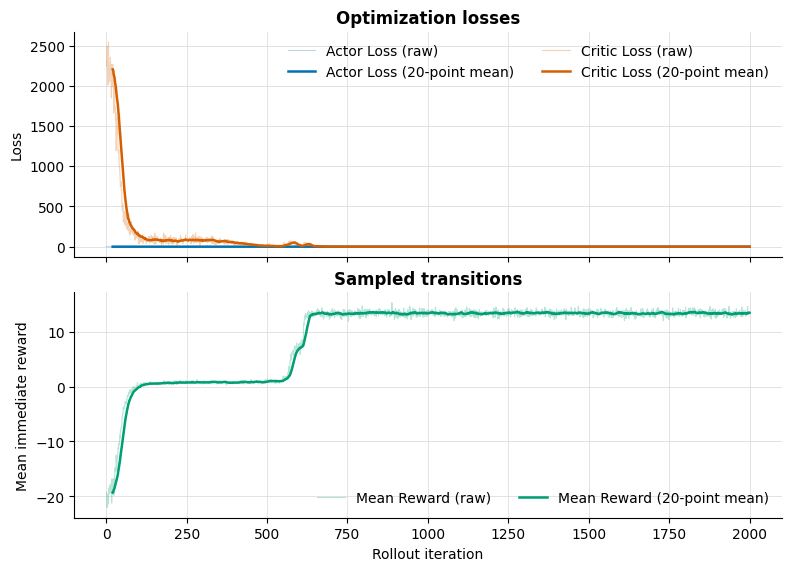

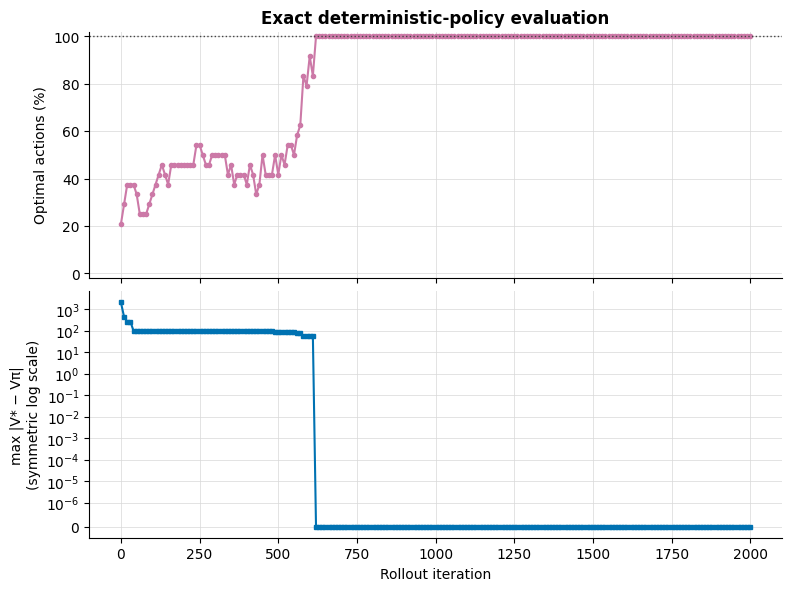

In [27]:
fig, axes = plot_training_curve(
    history,
    save_path=output_dir / 'ppo_training.png' if save_figures else None,
    show=False,
    smoothing_window=smoothing_window,
    dpi=figure_dpi,
)
if show_figures:
    display(fig)
plt.close(fig)

fig, axes = plot_evaluation_curve(
    evaluations,
    save_path=output_dir / 'ppo_evaluation.png' if save_figures else None,
    show=False,
    dpi=figure_dpi,
)
if show_figures:
    display(fig)
plt.close(fig)

## 7. 最终策略、Critic 与 baseline 对比

箭头表示 Actor 最大概率动作，圆圈表示停留，格内小数是所选动作概率。对比图的 `!` 表示该动作不属于 baseline 的最优动作集合。

{
  "nonterminal_states": 24,
  "optimal_action_fraction": 1.0,
  "mean_value_gap": -1.4802973661668755e-15,
  "max_value_gap": 0.0,
  "max_absolute_value_gap": 1.4210854715202004e-14,
  "mean_policy_value": 75.01443559808985,
  "mean_optimal_value": 75.01443559808985
}


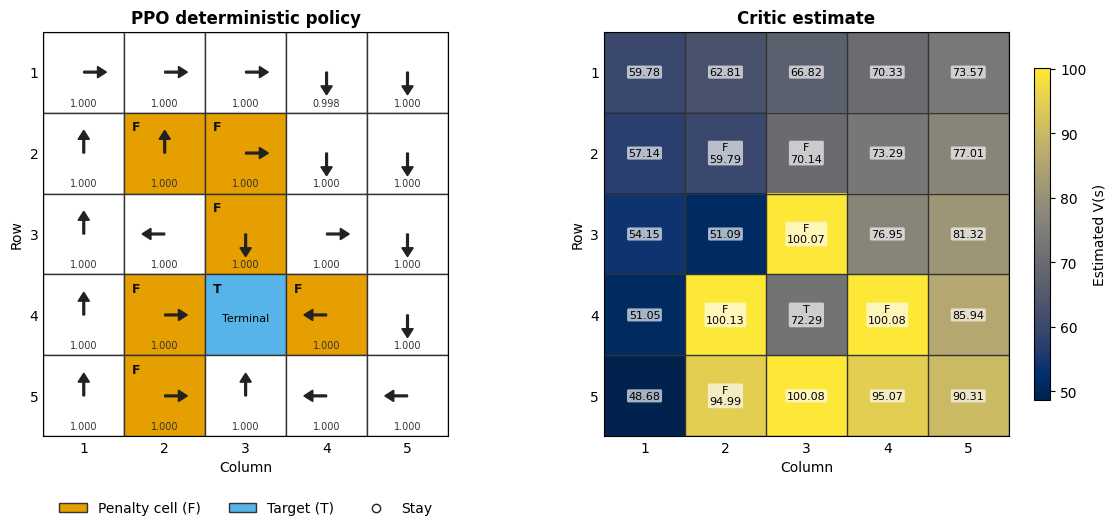

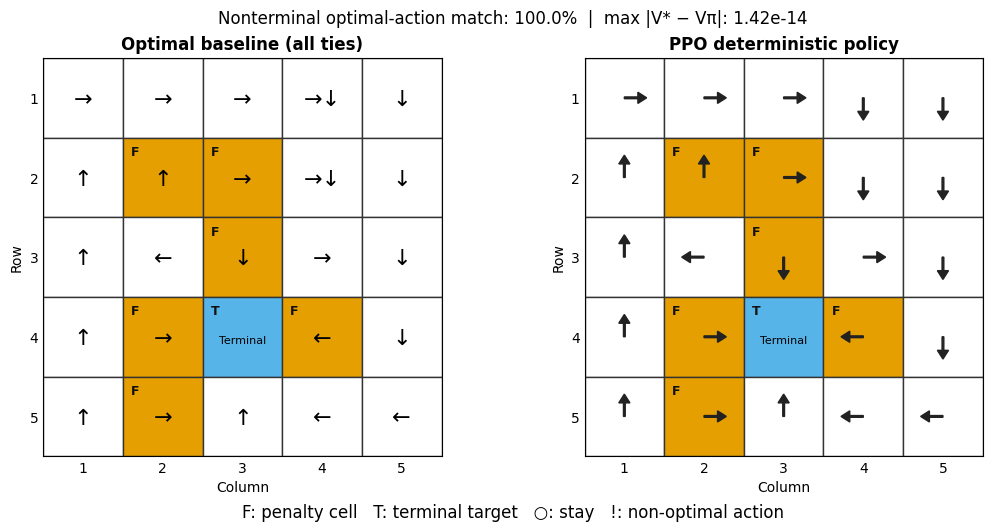

Learned deterministic policy (0=up, 1=right, 2=down, 3=left, 4=stay, -1=terminal):
[[ 1  1  1  2  2]
 [ 0  0  1  2  2]
 [ 0  3  2  1  2]
 [ 0  1 -1  3  2]
 [ 0  1  0  3  3]]
Exact value gap V* - V_pi:
[[ 0.  0.  0.  0.  0.]
 [-0. -0.  0.  0.  0.]
 [-0. -0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]]
Figures saved to: D:\My Knowledge\AI algorithm&architecture\Reinforcement-Learning\output\ppo


In [28]:
final_result = evaluate(runner, cfg, reference)
print(json.dumps(final_result['metrics'], indent=2, ensure_ascii=False))

fig, axes, learned_policy, diagnostics = plot_policy(
    runner, cfg,
    save_path=output_dir / 'ppo_policy_and_value.png' if save_figures else None,
    show=False, dpi=figure_dpi,
)
if show_figures:
    display(fig)
plt.close(fig)

fig, axes = plot_baseline_comparison(
    reference, final_result, cfg,
    save_path=output_dir / 'ppo_baseline_comparison.png' if save_figures else None,
    show=False, dpi=figure_dpi,
)
if show_figures:
    display(fig)
plt.close(fig)

shown_policy = learned_policy.copy()
shown_policy[reference['terminal_mask']] = -1
print('Learned deterministic policy (0=up, 1=right, 2=down, 3=left, 4=stay, -1=terminal):')
print(shown_policy)
print('Exact value gap V* - V_pi:')
print(np.array2string(final_result['value_gap'], precision=4, suppress_small=True))
if save_figures:
    print(f'Figures saved to: {output_dir.resolve()}')

## 8. 结果边界

baseline 是该固定、有限 GridWorld 配置下的精确动态规划参考。最优动作命中率和价值差只说明当前地图上的确定性 Actor 表现，不代表任意环境上的 PPO 收敛保证。